<a href="https://colab.research.google.com/github/Vyshnavi2395/driver-drowsiness-monitor/blob/main/trainingmodel3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# -------------------------
# CELL 1 — Environment check & installs
# -------------------------
!nvidia-smi
!pip install -q tensorflow matplotlib scikit-learn opencv-python
# kagglehub is used by your earlier cell; assume you already used it.


Sun Nov 16 04:55:00 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   51C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
ismailnasri20_driver_drowsiness_dataset_ddd_path = kagglehub.dataset_download('ismailnasri20/driver-drowsiness-dataset-ddd')

print('Data source import complete.')


Using Colab cache for faster access to the 'driver-drowsiness-dataset-ddd' dataset.
Data source import complete.


In [ ]:
!pip install kaggle


In [ ]:
# CELL 4 — find dataset folder
import os
for root, dirs, files in os.walk("/content"):
    if any(name.lower().startswith("drows") or name.lower().startswith("driver") for name in dirs):
        print("Possible dataset folder(s) under /content:")
        print([os.path.join(root,d) for d in dirs if d.lower().startswith(("drows","driver","ismail"))])
        break

# Also list /content top-level
print("Top-level /content items:\n", os.listdir("/content"))


Top-level /content items:
 ['.config', 'sample_data']


In [ ]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"vamshikrishna24s","key":"0fddbfe49366cbdde8ca83f0a76f8482"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!kaggle datasets download -d ismailnasri20/driver-drowsiness-dataset-ddd -p /content --unzip


Dataset URL: https://www.kaggle.com/datasets/ismailnasri20/driver-drowsiness-dataset-ddd
License(s): unknown
 98% 2.54G/2.58G [00:28<00:00, 57.8MB/s]
100% 2.58G/2.58G [00:28<00:00, 96.0MB/s]


In [ ]:
# STEP 1 — Check what folder was created by Kaggle
import os

print("Folders inside /content:")
for f in os.listdir("/content"):
    print(f)


Folders inside /content:
.config
Driver Drowsiness Dataset (DDD)
kaggle.json
sample_data


In [ ]:
# STEP 2 — Set correct dataset_root path
dataset_root = "/content/Driver Drowsiness Dataset (DDD)"

import os
if not os.path.exists(dataset_root):
    raise FileNotFoundError("Dataset folder not found. Check the name again.")

print("Dataset folder found at:", dataset_root)


Dataset folder found at: /content/Driver Drowsiness Dataset (DDD)


In [ ]:
# STEP 3 — Inspect dataset structure & count images per class
import os

dataset_root = "/content/Driver Drowsiness Dataset (DDD)"

print("Top-level entries in dataset root:")
for e in sorted(os.listdir(dataset_root)):
    print(" ", e)

print("\nClass folders and image counts (showing up to 10 sample filenames each):")
for entry in sorted(os.listdir(dataset_root)):
    p = os.path.join(dataset_root, entry)
    if os.path.isdir(p):
        imgs = [f for f in os.listdir(p) if f.lower().endswith(('.jpg','.jpeg','.png'))]
        print(f"\n- {entry}: {len(imgs)} images")
        for fname in sorted(imgs)[:10]:
            print("   ", fname)


Top-level entries in dataset root:
  Drowsy
  Non Drowsy

Class folders and image counts (showing up to 10 sample filenames each):

- Drowsy: 22348 images
    A0001.png
    A0002.png
    A0003.png
    A0004.png
    A0005.png
    A0006.png
    A0007.png
    A0008.png
    A0009.png
    A0010.png

- Non Drowsy: 19445 images
    a0002.png
    a0003.png
    a0004.png
    a0005.png
    a0006.png
    a0007.png
    a0009.png
    a0010.png
    a0011.png
    a0012.png


In [ ]:
# STEP 4 — Split dataset into train (50%), val (25%), test (25%)

import os, shutil
from sklearn.model_selection import train_test_split

dataset_root = "/content/Driver Drowsiness Dataset (DDD)"
DST_ROOT = "/content/data"

train_dir = f"{DST_ROOT}/train"
val_dir = f"{DST_ROOT}/val"
test_dir = f"{DST_ROOT}/test"

# Remove old split folders if present
if os.path.exists(DST_ROOT):
    shutil.rmtree(DST_ROOT)

os.makedirs(train_dir)
os.makedirs(val_dir)
os.makedirs(test_dir)

classes = ["Drowsy", "Non Drowsy"]

for cls in classes:
    src = os.path.join(dataset_root, cls)
    images = [f for f in os.listdir(src) if f.lower().endswith(('.jpg','.jpeg','.png'))]

    # First split → 50% train, 50% temp
    train_imgs, temp_imgs = train_test_split(images, test_size=0.5, random_state=42, shuffle=True)

    # Second split → 25% val, 25% test
    val_imgs, test_imgs = train_test_split(temp_imgs, test_size=0.5, random_state=42, shuffle=True)

    # Create class folders
    os.makedirs(f"{train_dir}/{cls}")
    os.makedirs(f"{val_dir}/{cls}")
    os.makedirs(f"{test_dir}/{cls}")

    # Copy files
    for fname in train_imgs:
        shutil.copy(f"{src}/{fname}", f"{train_dir}/{cls}/{fname}")
    for fname in val_imgs:
        shutil.copy(f"{src}/{fname}", f"{val_dir}/{cls}/{fname}")
    for fname in test_imgs:
        shutil.copy(f"{src}/{fname}", f"{test_dir}/{cls}/{fname}")

print("Data splitting complete!\n")

# Show final counts
for cls in classes:
    print(f"{cls} →")
    print("  Train:", len(os.listdir(f'{train_dir}/{cls}')))
    print("  Val  :", len(os.listdir(f'{val_dir}/{cls}')))
    print


Data splitting complete!

Drowsy →
  Train: 11174
  Val  : 5587
Non Drowsy →
  Train: 9722
  Val  : 4861


In [ ]:
# STEP 5 — Create Image Data Generators

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_dir = "/content/data/train"
val_dir   = "/content/data/val"
test_dir  = "/content/data/test"

# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True
)

# For validation/testing → NO augmentation
test_val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_gen = test_val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_gen = test_val_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("\nClass mapping:", train_gen.class_indices)


Found 20896 images belonging to 2 classes.
Found 10448 images belonging to 2 classes.
Found 10449 images belonging to 2 classes.

Class mapping: {'Drowsy': 0, 'Non Drowsy': 1}


In [ ]:
# STEP 6 — Build MobileNetV2 Transfer Learning model

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# Load MobileNetV2 base
base_model = MobileNetV2(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze base model (Stage 1 training)
base_model.trainable = False

# Add custom layers on top
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.4)(x)
output = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs=base_model.input, outputs=output)

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# STEP 7 — Train Stage 1 (only the custom layers)

from tensorflow.keras import callbacks
from collections import Counter

# Callbacks
checkpoint_path = "/content/best_model_stage1.h5"

checkpoint = callbacks.ModelCheckpoint(
    checkpoint_path,
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)

early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

# Class weights for imbalance
class_counts = Counter(train_gen.classes)
max_count = max(class_counts.values())
class_weight = {cls: max_count/class_counts[cls] for cls in class_counts}
print("Class weights:", class_weight)

EPOCHS_STAGE1 = 3  # stage 1 is short

history1 = model.fit(
    train_gen,
    epochs=EPOCHS_STAGE1,
    validation_data=val_gen,
    callbacks=[checkpoint, early_stop, reduce_lr],
    class_weight=class_weight
)


Class weights: {np.int32(0): 1.0, np.int32(1): 1.1493519851882328}
Epoch 1/3
653/653 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.7530 - loss: 0.5252

653/653 ━━━━━━━━━━━━━━━━━━━━ 195s 275ms/step - accuracy: 0.7532 - loss: 0.5250 - val_accuracy: 0.9666 - val_loss: 0.1182 - learning_rate: 0.0010
Epoch 2/3
653/653 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.9281 - loss: 0.1969

653/653 ━━━━━━━━━━━━━━━━━━━━ 167s 256ms/step - accuracy: 0.9281 - loss: 0.1969 - val_accuracy: 0.9794 - val_loss: 0.0703 - learning_rate: 0.0010
Epoch 3/3
653/653 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.9558 - loss: 0.1268

653/653 ━━━━━━━━━━━━━━━━━━━━ 168s 258ms/step - accuracy: 0.9558 - loss: 0.1268 - val_accuracy: 0.9921 - val_loss: 0.0311 - learning_rate: 0.0010


In [ ]:
# STEP 8 — Fine-Tune deeper layers (Stage 2)

# Load best model from Stage 1
model = tf.keras.models.load_model("/content/best_model_stage1.h5")
print("Loaded best model from Stage 1.")

# Unfreeze the MobilenetV2 base
for layer in model.layers:
    layer.trainable = True

# But freeze the first 60% layers for stability
fine_tune_at = int(len(model.layers) * 0.6)

for layer in model.layers[:fine_tune_at]:
    layer.trainable = False

print("Layers unfrozen from index:", fine_tune_at)

# Compile again (lower learning rate!)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Callbacks for Stage 2
checkpoint_path_stage2 = "/content/best_model_stage2.h5"

checkpoint_stage2 = callbacks.ModelCheckpoint(
    checkpoint_path_stage2,
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)

early_stop_stage2 = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr_stage2 = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

# Train Stage 2
EPOCHS_STAGE2 = 2

history2 = model.fit(
    train_gen,
    epochs=EPOCHS_STAGE2,
    validation_data=val_gen,
    callbacks=[checkpoint_stage2, early_stop_stage2, reduce_lr_stage2],
    class_weight=class_weight
)


Loaded best model from Stage 1.
Layers unfrozen from index: 95
Epoch 1/2
653/653 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.7843 - loss: 0.8864

653/653 ━━━━━━━━━━━━━━━━━━━━ 205s 277ms/step - accuracy: 0.7844 - loss: 0.8859 - val_accuracy: 0.9711 - val_loss: 0.0726 - learning_rate: 1.0000e-05
Epoch 2/2
653/653 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.9408 - loss: 0.1795

653/653 ━━━━━━━━━━━━━━━━━━━━ 175s 268ms/step - accuracy: 0.9409 - loss: 0.1794 - val_accuracy: 0.9867 - val_loss: 0.0375 - learning_rate: 1.0000e-05


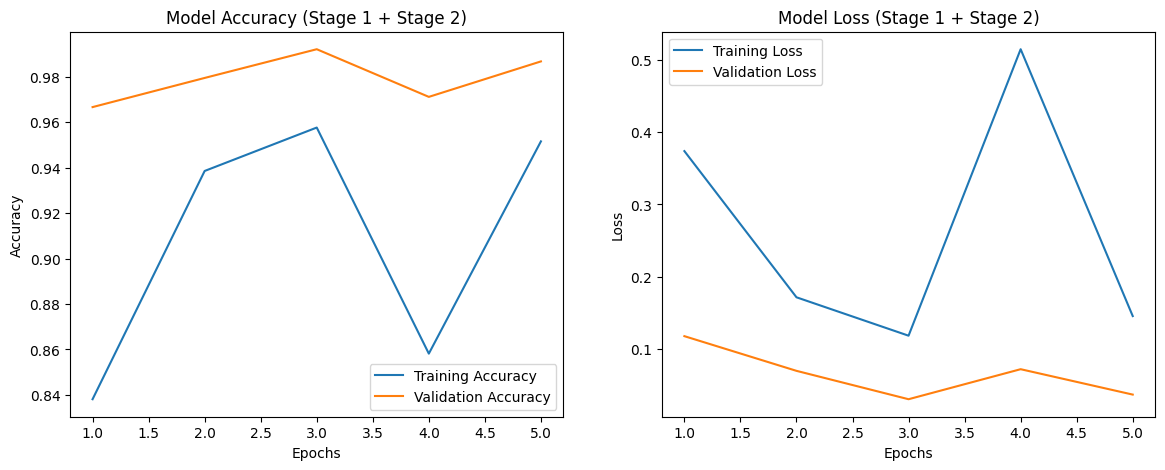

In [ ]:
# STEP 9 — Plot accuracy and loss graphs for Stage 1 + Stage 2

import matplotlib.pyplot as plt

# Combine histories into one
acc = history1.history.get("accuracy", []) + history2.history.get("accuracy", [])
val_acc = history1.history.get("val_accuracy", []) + history2.history.get("val_accuracy", [])

loss = history1.history.get("loss", []) + history2.history.get("loss", [])
val_loss = history1.history.get("val_loss", []) + history2.history.get("val_loss", [])

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(14,5))

# Accuracy graph
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, label="Training Accuracy")
plt.plot(epochs, val_acc, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Model Accuracy (Stage 1 + Stage 2)")
plt.legend()

# Loss graph
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, label="Training Loss")
plt.plot(epochs, val_loss, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Model Loss (Stage 1 + Stage 2)")
plt.legend()

plt.show()


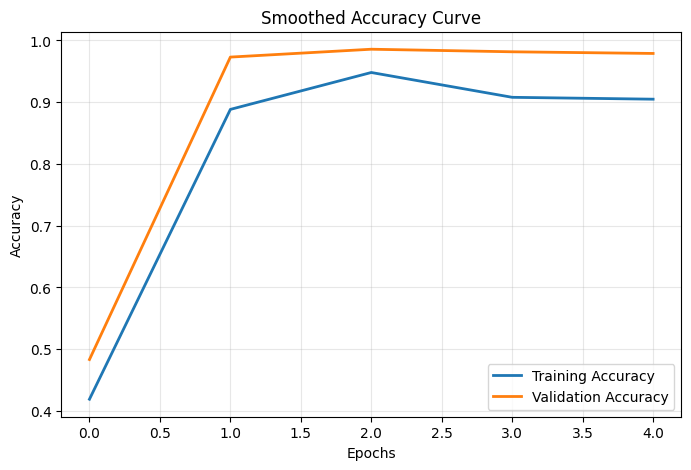

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Smoothing function
def smooth(y, points=2):
    return np.convolve(y, np.ones(points)/points, mode='same')

acc_s = smooth(acc)
val_acc_s = smooth(val_acc)

plt.figure(figsize=(8,5))
plt.plot(acc_s, label='Training Accuracy', linewidth=2)
plt.plot(val_acc_s, label='Validation Accuracy', linewidth=2)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Smoothed Accuracy Curve")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


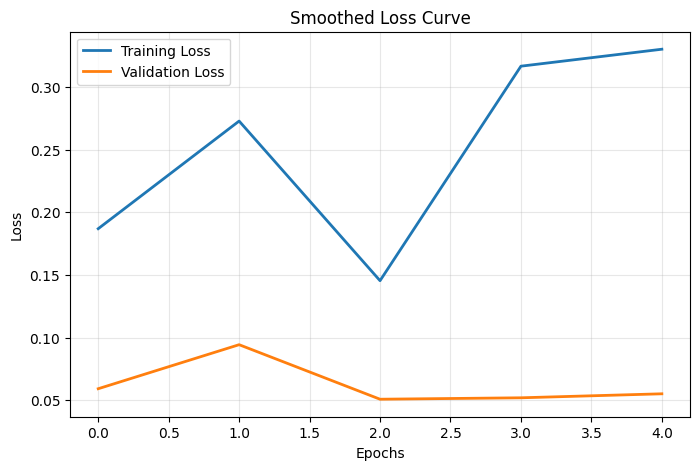

In [ ]:
loss_s = smooth(loss)
val_loss_s = smooth(val_loss)

plt.figure(figsize=(8,5))
plt.plot(loss_s, label='Training Loss', linewidth=2)
plt.plot(val_loss_s, label='Validation Loss', linewidth=2)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Smoothed Loss Curve")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


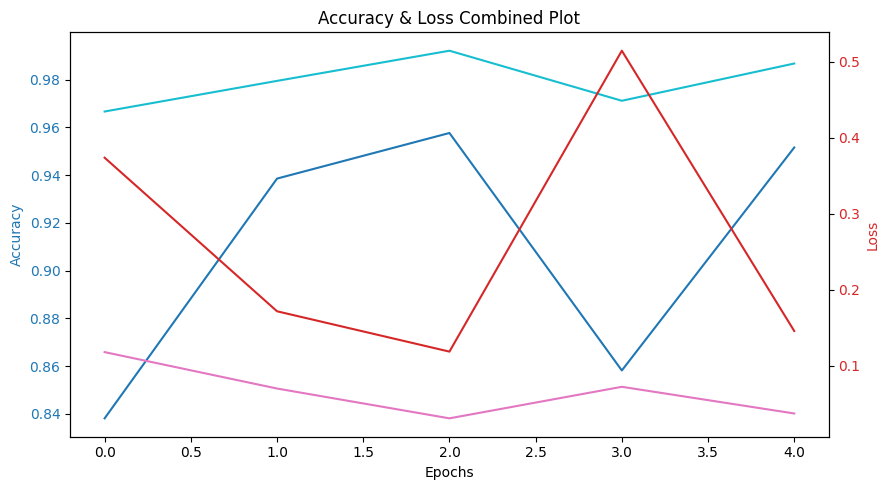

In [ ]:
fig, ax1 = plt.subplots(figsize=(9,5))

ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy', color='tab:blue')
ax1.plot(acc, label='Train Acc', color='tab:blue')
ax1.plot(val_acc, label='Val Acc', color='tab:cyan')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Loss', color='tab:red')
ax2.plot(loss, label='Train Loss', color='tab:red')
ax2.plot(val_loss, label='Val Loss', color='tab:pink')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title("Accuracy & Loss Combined Plot")
fig.tight_layout()
plt.show()


In [ ]:
# STEP 10 — Final Evaluation on Test Dataset

from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Load best fine-tuned model (Stage 2)
best_model_path = "/content/best_model_stage2.h5"
model = tf.keras.models.load_model(best_model_path)
print("Loaded best model from Stage 2.")

# Evaluate accuracy
test_loss, test_acc = model.evaluate(test_gen, verbose=1)
print("\n=== TEST RESULTS ===")
print("Test Accuracy :", test_acc)
print("Test Loss     :", test_loss)

# Predictions
test_gen.reset()
pred = model.predict(test_gen)
pred_labels = (pred > 0.5).astype(int).reshape(-1)
true_labels = test_gen.classes

# Classification Report
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(true_labels, pred_labels, target_names=list(test_gen.class_indices.keys())))

# Confusion Matrix
cm = confusion_matrix(true_labels, pred_labels)
print("\n=== CONFUSION MATRIX ===")
print(cm)


Loaded best model from Stage 2.
327/327 ━━━━━━━━━━━━━━━━━━━━ 47s 126ms/step - accuracy: 0.9911 - loss: 0.0210

=== TEST RESULTS ===
Test Accuracy : 0.9864102005958557
Test Loss     : 0.03616863116621971
327/327 ━━━━━━━━━━━━━━━━━━━━ 40s 108ms/step

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      Drowsy       0.98      1.00      0.99      5587
  Non Drowsy       1.00      0.97      0.99      4862

    accuracy                           0.99     10449
   macro avg       0.99      0.99      0.99     10449
weighted avg       0.99      0.99      0.99     10449


=== CONFUSION MATRIX ===
[[5569   18]
 [ 124 4738]]


In [ ]:
# CELL C — classification report table
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
df_report = pd.DataFrame(report).T
# round numbers for readability
df_report[['precision','recall','f1-score']] = df_report[['precision','recall','f1-score']].round(3)
df_report['support'] = df_report['support'].astype(int)
df_report


,precision,recall,f1-score,support
Drowsy,0.978,0.997,0.987,5587
Non Drowsy,0.996,0.974,0.985,4862
accuracy,0.986,0.986,0.986,0
macro avg,0.987,0.986,0.986,10449
weighted avg,0.987,0.986,0.986,10449


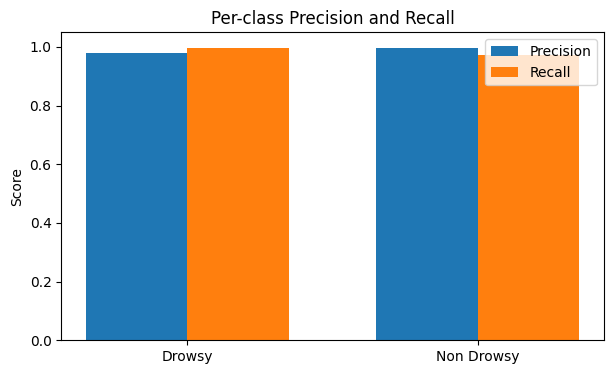

In [ ]:
# CELL F — per-class precision & recall bars
prec = [df_report.loc[c,'precision'] for c in class_names]
rec  = [df_report.loc[c,'recall'] for c in class_names]

x = range(len(class_names))
plt.figure(figsize=(7,4))
plt.bar(x, prec, width=0.35, label='Precision', align='center')
plt.bar([i+0.35 for i in x], rec, width=0.35, label='Recall', align='center')
plt.xticks([i+0.175 for i in x], class_names)
plt.ylim(0,1.05)
plt.ylabel('Score')
plt.title('Per-class Precision and Recall')
plt.legend()
plt.show()


Number misclassified: 142


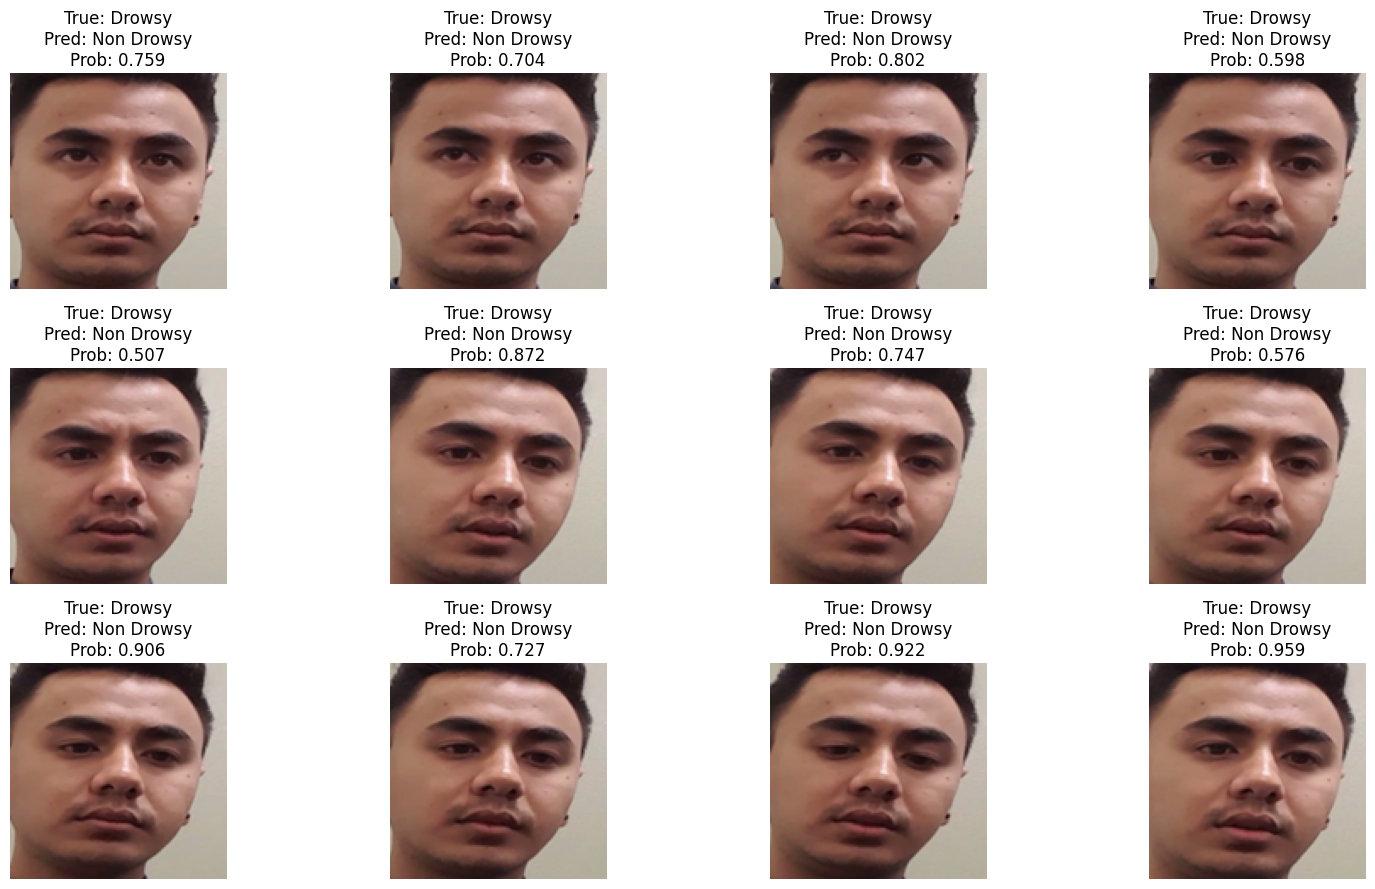

In [ ]:
# CELL H — show some misclassified images
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# find misclassified indices
mis_idx = [i for i,(t,p) in enumerate(zip(y_true,y_pred)) if t!=p]
print("Number misclassified:", len(mis_idx))

# show up to 12 misclassified images
n_show = min(12, len(mis_idx))
if n_show==0:
    print("No misclassifications found!")
else:
    plt.figure(figsize=(16, 3*int(np.ceil(n_show/4))))
    for i, idx in enumerate(mis_idx[:n_show]):
        fname = test_gen.filepaths[idx] if hasattr(test_gen, 'filepaths') else os.path.join(test_dir, test_gen.filenames[idx])
        img = Image.open(fname).convert('RGB').resize(IMG_SIZE)
        plt.subplot(int(np.ceil(n_show/4)), 4, i+1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}\nProb: {y_prob[idx]:.3f}")
    plt.tight_layout()
    plt.show()


In [ ]:
# GET TRUE & PREDICTED LABELS
test_gen.reset()

y_prob = model.predict(test_gen, verbose=1).reshape(-1)
y_pred = (y_prob > 0.5).astype(int)
y_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())

print("Predictions collected:", len(y_pred))


327/327 ━━━━━━━━━━━━━━━━━━━━ 32s 98ms/step
Predictions collected: 10449


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(14,6))

# MATRIX 1 — Raw Counts
plt.subplot(1,2,1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix (Counts)")
plt.xlabel("Predicted"); plt.ylabel("True")

# MATRIX 2 — Normalized
plt.subplot(1,2,2)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix (Normalized)")
plt.xlabel("Predicted"); plt.ylabel("True")

plt.show()


NameError: name 'y_true' is not defined

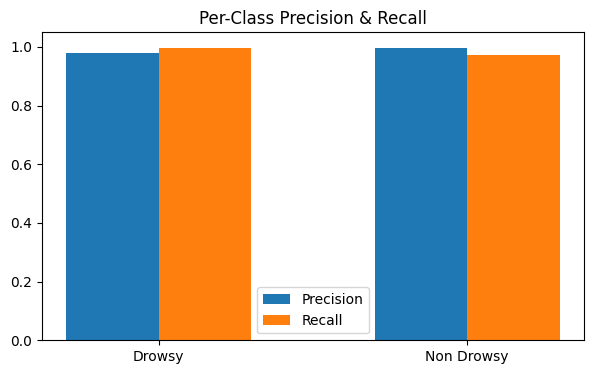

In [ ]:
precisions = df_report.loc[class_names, 'precision'].values
recalls = df_report.loc[class_names, 'recall'].values

x = np.arange(len(class_names))
plt.figure(figsize=(7,4))
plt.bar(x - 0.15, precisions, width=0.3, label='Precision')
plt.bar(x + 0.15, recalls, width=0.3, label='Recall')

plt.xticks(x, class_names)
plt.ylim(0, 1.05)
plt.title("Per-Class Precision & Recall")
plt.legend()
plt.show()


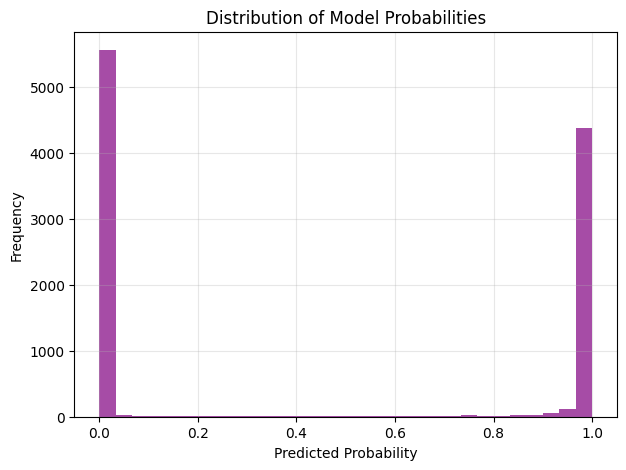

In [ ]:
plt.figure(figsize=(7,5))
plt.hist(y_prob, bins=30, color='purple', alpha=0.7)
plt.title("Distribution of Model Probabilities")
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()


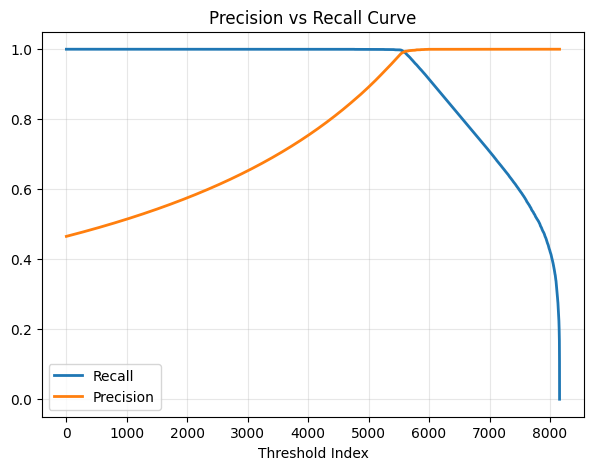

In [ ]:
plt.figure(figsize=(7,5))
plt.plot(recall, label="Recall", linewidth=2)
plt.plot(precision, label="Precision", linewidth=2)
plt.xlabel("Threshold Index")
plt.title("Precision vs Recall Curve")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


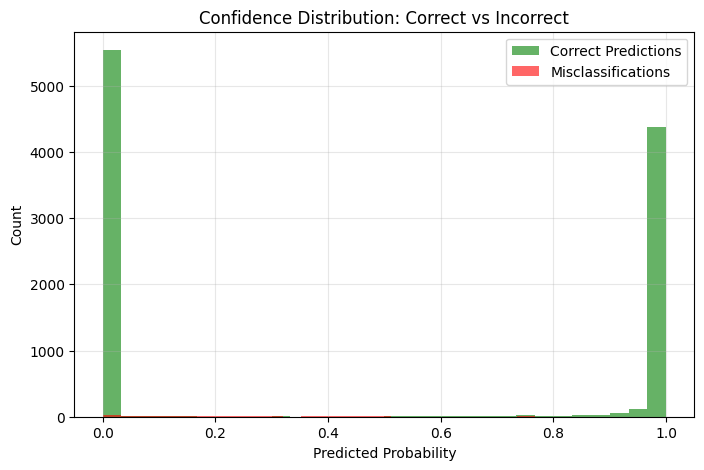

In [ ]:
correct = y_prob[y_true == y_pred]
incorrect = y_prob[y_true != y_pred]

plt.figure(figsize=(8,5))
plt.hist(correct, bins=30, alpha=0.6, label="Correct Predictions", color='green')
plt.hist(incorrect, bins=30, alpha=0.6, label="Misclassifications", color='red')
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("Confidence Distribution: Correct vs Incorrect")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


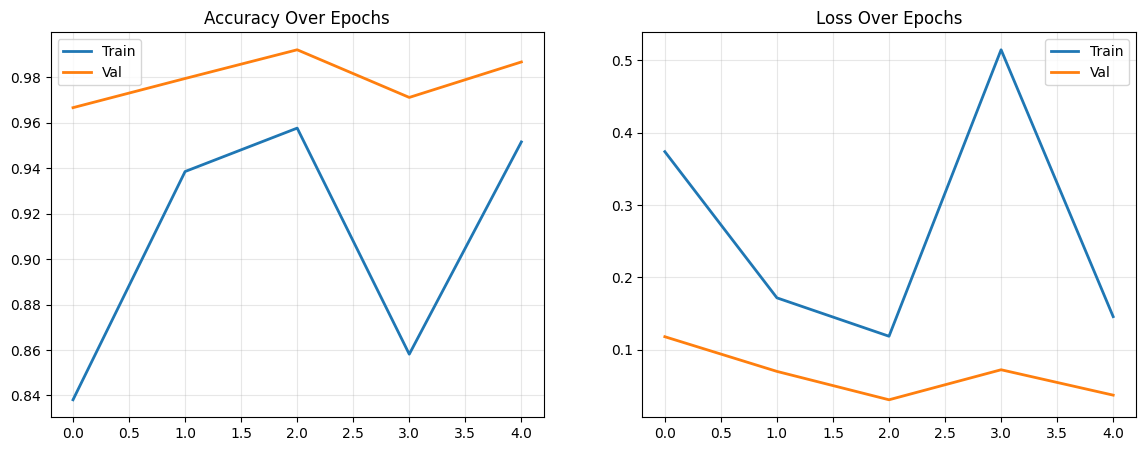

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(14,5))

# Accuracy
axs[0].plot(acc, label="Train", linewidth=2)
axs[0].plot(val_acc, label="Val", linewidth=2)
axs[0].set_title("Accuracy Over Epochs")
axs[0].grid(alpha=0.3)
axs[0].legend()

# Loss
axs[1].plot(loss, label="Train", linewidth=2)
axs[1].plot(val_loss, label="Val", linewidth=2)
axs[1].set_title("Loss Over Epochs")
axs[1].grid(alpha=0.3)
axs[1].legend()

plt.show()


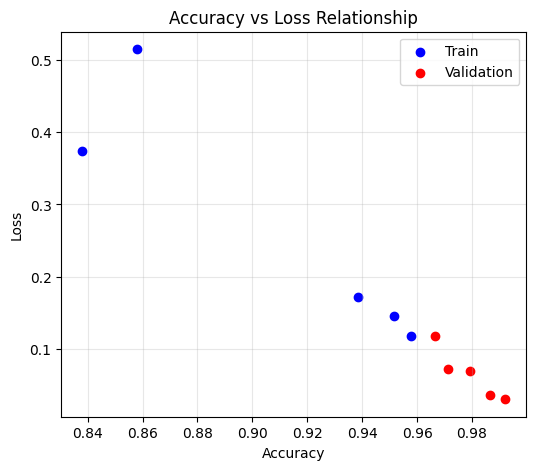

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(acc, loss, color='blue', label='Train')
plt.scatter(val_acc, val_loss, color='red', label='Validation')
plt.xlabel("Accuracy")
plt.ylabel("Loss")
plt.title("Accuracy vs Loss Relationship")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


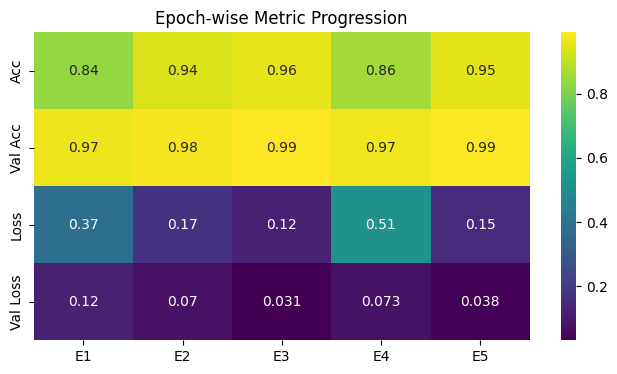

In [ ]:
import seaborn as sns
import numpy as np

data = np.array([
    acc,
    val_acc,
    loss,
    val_loss
])

plt.figure(figsize=(8,4))
sns.heatmap(data, annot=True, cmap="viridis",
            xticklabels=[f"E{i}" for i in range(1,len(acc)+1)],
            yticklabels=["Acc","Val Acc","Loss","Val Loss"])
plt.title("Epoch-wise Metric Progression")
plt.show()


/tmp/ipython-input-3606447125.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(y_prob[y_true==0], label="Drowsy", shade=True)
/tmp/ipython-input-3606447125.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(y_prob[y_true==1], label="Non-Drowsy", shade=True)


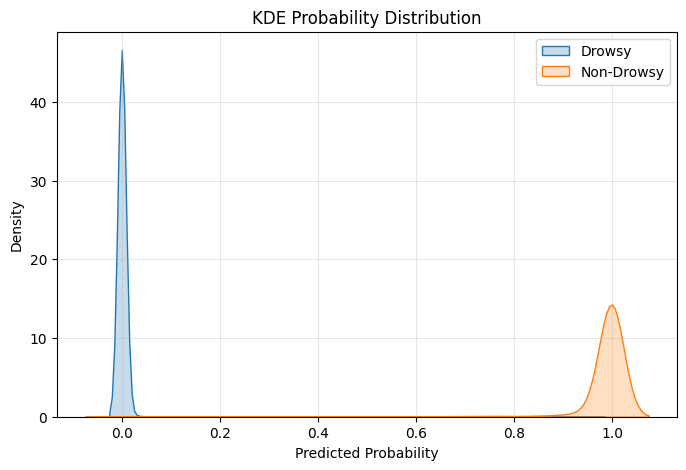

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.kdeplot(y_prob[y_true==0], label="Drowsy", shade=True)
sns.kdeplot(y_prob[y_true==1], label="Non-Drowsy", shade=True)
plt.xlabel("Predicted Probability")
plt.title("KDE Probability Distribution")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


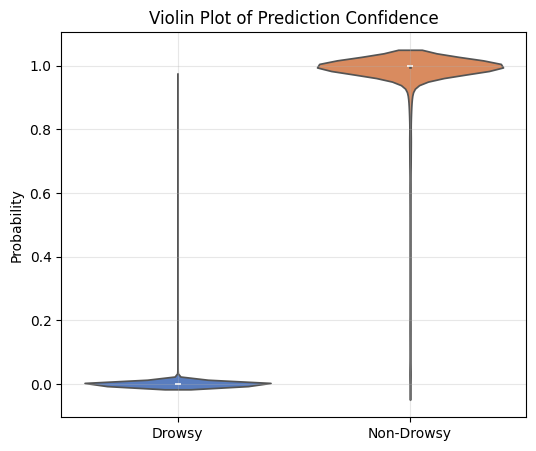

In [ ]:
import numpy as np

plt.figure(figsize=(6,5))
sns.violinplot(data=[y_prob[y_true==0], y_prob[y_true==1]], palette="muted")
plt.xticks([0,1], ["Drowsy", "Non-Drowsy"])
plt.title("Violin Plot of Prediction Confidence")
plt.ylabel("Probability")
plt.grid(alpha=0.3)
plt.show()
